## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings, datetime, pathlib, os, textwrap
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")



## Load file


In [3]:
df = pd.read_csv('Austin_Weather_Cleaned_99_23.csv', parse_dates=['Date'])
print('Shape:', df.shape)
df.head()

Shape: (10354, 27)


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events,...,HumidityCategory,TempAvgF_squared,HumidityAvgPercent_squared,Pressure_squared,HeatIndex,TempPressure,PrevDayTemp,PrevDayHumidity,TempAvg_7day,HumidityAvg_7day
0,1999-01-01,73.9,51.8,60.5,57.9,92.0,1008.7,4.2,0.0,NaN,...,Very Humid,3660.25,8464.00,1017475.69,5566.00,61026.35,NaN,NaN,60.500,92.000000
1,1999-01-02,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,NaN,...,Moderate,2323.24,2714.41,1033475.56,2511.22,49000.12,60.5,92.0,54.350,72.050000
2,1999-01-03,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,NaN,...,Dry,1267.36,1521.00,1060488.04,1388.40,36660.88,48.2,52.1,48.100,61.033333
3,1999-01-04,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,NaN,...,Dry,1169.64,1909.69,1071018.01,1494.54,35393.58,35.6,39.0,44.625,56.700000
4,1999-01-05,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,NaN,...,Humid,1576.09,5270.76,1054112.89,2882.22,40759.99,34.2,43.7,43.640,59.880000


## Heavy precipitation events

In [4]:

wet = df[df['PrecipitationSumInches'] > 0]
prcp_thresh = wet['PrecipitationSumInches'].quantile(.95) #change the number here to choose what upper quantile you want to count as "heavy precipitation"
df['heavy_rain'] = df['PrecipitationSumInches'] >= prcp_thresh
heavy = df[df['heavy_rain']].copy()
heavy['type'] = 'HeavyRain'
print(f'{heavy.shape[0]} heavy-rain days (≥{prcp_thresh:.2f} in)')

144 heavy-rain days (≥1.49 in)


## What months have the most heavy rain days


Heavy-rain days 144


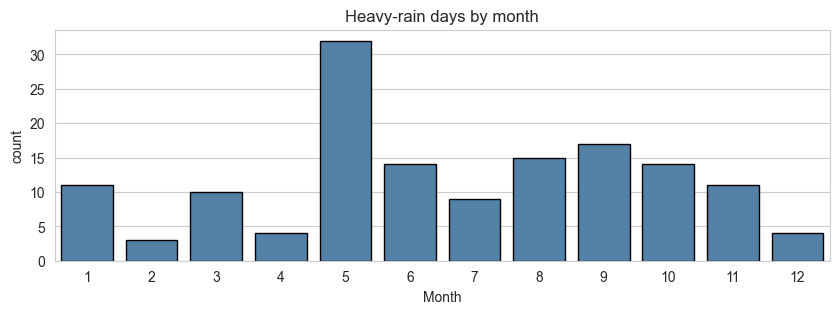

In [5]:
heavy = df[df['heavy_rain']].copy()     
print('Heavy-rain days', heavy.shape[0])
heavy.head()

plt.figure(figsize=(10,3))
sns.countplot(data=heavy, x='Month', color='steelblue', edgecolor='k')
plt.title('Heavy-rain days by month')
plt.show()



## Are heavy rain days becoming more common?


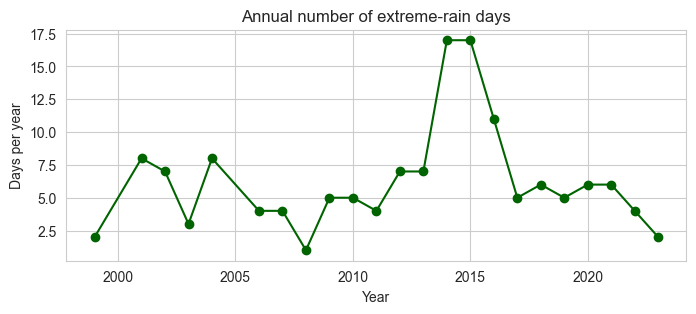

Trend = 0.07 extra days per year  (p=0.562)


In [6]:
# annual count
yr_counts = heavy.groupby('Year').size()
plt.figure(figsize=(8,3))
yr_counts.plot(marker='o', color='darkgreen')
plt.title('Annual number of extreme-rain days')
plt.ylabel('Days per year')
plt.show()

# simple linear trend
from scipy import stats
slope, intercept, r, p, se = stats.linregress(yr_counts.index, yr_counts.values)
print(f'Trend = {slope:.2f} extra days per year  (p={p:.3f})')

## See if heavy rain correlates with high temperatures


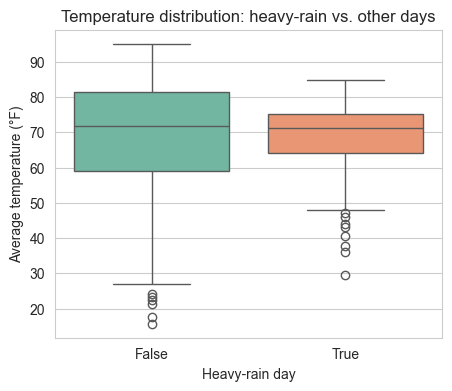

Mean temp on heavy-rain days:  68.2 °F
Mean temp on other days:       69.5 °F
Difference:                    -1.3 °F
Two-sample t-test: t=-1.45, p=0.1479
→ No significant temperature difference.


In [8]:
df['is_heavy'] = df['heavy_rain']        # True/False → easier name
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x='is_heavy', y='TempAvgF', palette='Set2')
plt.title('Temperature distribution: heavy-rain vs. other days')
plt.xlabel('Heavy-rain day')
plt.ylabel('Average temperature (°F)')
plt.show()

heavy_t  = df.loc[df['heavy_rain'], 'TempAvgF']
normal_t = df.loc[~df['heavy_rain'], 'TempAvgF']

print(f'Mean temp on heavy-rain days:  {heavy_t.mean():.1f} °F')
print(f'Mean temp on other days:       {normal_t.mean():.1f} °F')
print(f'Difference:                    {heavy_t.mean() - normal_t.mean():.1f} °F')

# two-sample t-test
from scipy.stats import ttest_ind
t_stat, p = ttest_ind(heavy_t, normal_t, equal_var=False)
print(f'Two-sample t-test: t={t_stat:.2f}, p={p:.4f}')
if p < 0.05:
    print("→ Difference is statistically significant.")
else:
    print("→ No significant temperature difference.")
